# Assignment 2 — K-Means Clustering (100% Manual, No Libraries)

**Dataset:** Country socio-economic data (`exports`, `imports`, `income`, `gdpp`) for 167 countries.

**Goal:** Implement K-Means Clustering **completely from scratch using pure Python** — plain `list`s, `for` loops, and the built-in `math` module only. **No `numpy`, no `pandas`, no `sklearn` anywhere.** The only external library used is `matplotlib`, and only at the very end, purely to *draw* the charts — it plays no role in the algorithm or the math itself.

### Algorithm (as per assignment brief)
1. Choose the number of clusters, K.
2. Randomly select K data points as the initial centroids.
3. Calculate the distance from each data point to every centroid using Euclidean distance:
$$d = \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2 + \dots}$$
4. Assign each data point to the cluster whose centroid is closest.
5. Recalculate the centroid of each cluster (mean of all points assigned to it).
6. Repeat steps 3–5 until centroids stop changing significantly, or a max iteration limit is hit.
7. The final groups are the K clusters.

Run for **K = 2, 3, 4, 5**, then evaluate quality using two manually-coded metrics: **WCSS (Elbow Method)** and **Silhouette Score**.


## 1. Load the Dataset (pure Python — `csv` module only)

The dataset is embedded as CSV text below so the notebook is self-contained. We read it with Python's built-in `csv` module — **not** `pandas`.


In [ ]:
import csv
import io
import math
import random

csv_text = """country,exports,imports,income,gdpp
Afghanistan,10,44.9,1610,553
Albania,28,48.6,9930,4090
Algeria,38.4,31.4,12900,4460
Angola,62.3,42.9,5900,3530
Antigua and Barbuda,45.5,58.9,19100,12200
Argentina,18.9,16,18700,10300
Armenia,20.8,45.3,6700,3220
Australia,19.8,20.9,41400,51900
Austria,51.3,47.8,43200,46900
Azerbaijan,54.3,20.7,16000,5840
Bahamas,35,43.7,22900,28000
Bahrain,69.5,50.9,41100,20700
Bangladesh,16,21.8,2440,758
Barbados,39.5,48.7,15300,16000
Belarus,51.4,64.5,16200,6030
Belgium,76.4,74.7,41100,44400
Belize,58.2,57.5,7880,4340
Benin,23.8,37.2,1820,758
Bhutan,42.5,70.7,6420,2180
Bolivia,41.2,34.3,5410,1980
Bosnia and Herzegovina,29.7,51.3,9720,4610
Botswana,43.6,51.3,13300,6350
Brazil,10.7,11.8,14500,11200
Brunei,67.4,28,80600,35300
Bulgaria,50.2,53,15300,6840
Burkina Faso,19.2,29.6,1430,575
Burundi,8.92,39.2,764,231
Cambodia,54.1,59.5,2520,786
Cameroon,22.2,27,2660,1310
Canada,29.1,31,40700,47400
Cape Verde,32.7,61.8,5830,3310
Central African Republic,11.8,26.5,888,446
Chad,36.8,43.5,1930,897
Chile,37.7,31.3,19400,12900
China,26.3,22.6,9530,4560
Colombia,15.9,17.8,10900,6250
Comoros,16.5,51.7,1410,769
"Congo, Dem. Rep.",41.1,49.6,609,334
"Congo, Rep.",85.1,54.7,5190,2740
Costa Rica,33.2,35,13000,8200
Cote d'Ivoire,50.6,43.3,2690,1220
Croatia,37.6,38.1,20100,13500
Cyprus,50.2,57.5,33900,30800
Czech Republic,66,62.9,28300,19800
Denmark,50.5,43.6,44000,58000
Dominican Republic,22.7,33.3,11100,5450
Ecuador,27.9,32.4,9350,4660
Egypt,21.3,26.6,9860,2600
El Salvador,26.9,46.6,7300,2990
Equatorial Guinea,85.8,58.9,33700,17100
Eritrea,4.79,23.3,1420,482
Estonia,75.1,68.7,22700,14600
Fiji,57.8,63.9,7350,3650
Finland,38.7,37.4,39800,46200
France,26.8,28.1,36900,40600
Gabon,57.7,18.9,15400,8750
Gambia,23.8,42.7,1660,562
Georgia,35,52.8,6730,2960
Germany,42.3,37.1,40400,41800
Ghana,29.5,45.9,3060,1310
Greece,22.1,30.7,28700,26900
Grenada,23.8,49.2,11200,7370
Guatemala,25.8,36.3,6710,2830
Guinea,30.3,43.2,1190,648
Guinea-Bissau,14.9,35.2,1390,547
Guyana,51.4,79.1,5840,3040
Haiti,15.3,64.7,1500,662
Hungary,81.8,76.5,22300,13100
Iceland,53.4,43.3,38800,41900
India,22.6,27.1,4410,1350
Indonesia,24.3,22.4,8430,3110
Iran,24.4,19.4,17400,6530
Iraq,39.4,34.1,12700,4500
Ireland,103,86.5,45700,48700
Israel,35,32.9,29600,30600
Italy,25.2,27.2,36200,35800
Jamaica,31.3,49.6,8000,4680
Japan,15,13.6,35800,44500
Jordan,48.3,69,9470,3680
Kazakhstan,44.2,29.9,20100,9070
Kenya,20.7,33.6,2480,967
Kiribati,13.3,79.9,1730,1490
Kuwait,66.7,30.4,75200,38500
Kyrgyz Republic,51.6,81.7,2790,880
Lao,35.4,49.3,3980,1140
Latvia,53.7,55.1,18300,11300
Lebanon,35.8,60.2,16300,8860
Lesotho,39.4,101,2380,1170
Liberia,19.1,92.6,700,327
Libya,65.6,42.1,29600,12100
Lithuania,65.3,67.2,21100,12000
Luxembourg,175,142,91700,105000
"Macedonia, FYR",39.8,58.1,11400,4540
Madagascar,25,43,1390,413
Malawi,22.8,34.9,1030,459
Malaysia,86.9,71,21100,9070
Maldives,77.6,65.4,10500,7100
Mali,22.8,35.1,1870,708
Malta,153,154,28300,21100
Mauritania,50.7,61.2,3320,1200
Mauritius,51.2,62.2,15900,8000
"Micronesia, Fed. Sts.",23.5,81,3340,2860
Moldova,39.2,78.5,3910,1630
Mongolia,46.7,56.7,7710,2650
Montenegro,37,62.7,14000,6680
Morocco,32.2,43,6440,2830
Mozambique,31.5,46.2,918,419
Myanmar,0.109,0.0659,3720,988
Namibia,47.8,60.7,8460,5190
Nepal,9.58,36.4,1990,592
Netherlands,72,63.6,45500,50300
New Zealand,30.3,28,32300,33700
Niger,22.2,49.1,814,348
Nigeria,25.3,17.4,5150,2330
Norway,39.7,28.5,62300,87800
Oman,65.7,41.2,45300,19300
Pakistan,13.5,19.4,4280,1040
Panama,70,78.2,15400,8080
Paraguay,55.1,51.5,7290,3230
Peru,27.8,23.8,9960,5020
Philippines,34.8,36.6,5600,2130
Poland,40.1,42.1,21800,12600
Portugal,29.9,37.4,27200,22500
Qatar,62.3,23.8,125000,70300
Romania,32.6,38.8,17800,8230
Russia,29.2,21.1,23100,10700
Rwanda,12,30,1350,563
Samoa,29.2,53.1,5400,3450
Saudi Arabia,49.6,33,45400,19300
Senegal,24.9,40.3,2180,1000
Serbia,32.9,47.9,12700,5410
Seychelles,93.8,108,20400,10800
Sierra Leone,16.8,34.5,1220,399
Singapore,200,174,72100,46600
Slovak Republic,76.3,77.8,25200,16600
Slovenia,64.3,62.9,28700,23400
Solomon Islands,49.3,81.2,1780,1290
South Africa,28.6,27.4,12000,7280
South Korea,49.4,46.2,30400,22100
Spain,25.5,26.8,32500,30700
Sri Lanka,19.6,26.8,8560,2810
St. Vincent and the Grenadines,26.9,57.1,9920,6230
Sudan,19.7,17.2,3370,1480
Suriname,52.5,38.4,14200,8300
Sweden,46.2,40.7,42900,52100
Switzerland,64,53.3,55500,74600
Tajikistan,14.9,58.6,2110,738
Tanzania,18.7,29.1,2090,702
Thailand,66.5,60.8,13500,5080
Timor-Leste,2.2,27.8,1850,3600
Togo,40.2,57.3,1210,488
Tonga,12.4,60.3,4980,3550
Tunisia,50.5,55.3,10400,4140
Turkey,20.4,25.5,18000,10700
Turkmenistan,76.3,44.5,9940,4440
Uganda,17.1,28.6,1540,595
Ukraine,47.1,51.1,7820,2970
United Arab Emirates,77.7,63.6,57600,35000
United Kingdom,28.2,30.8,36200,38900
United States,12.4,15.8,49400,48400
Uruguay,26.3,25.4,17100,11900
Uzbekistan,31.7,28.5,4240,1380
Vanuatu,46.6,52.7,2950,2970
Venezuela,28.5,17.6,16500,13500
Vietnam,72,80.2,4490,1310
Yemen,30,34.4,4480,1310
Zambia,37,30.9,3280,1460
"""

reader = csv.DictReader(io.StringIO(csv_text))
rows = list(reader)

print("Number of countries:", len(rows))
print("Columns:", list(rows[0].keys()))
print("First row:", rows[0])


Number of countries: 167
Columns: ['country', 'exports', 'imports', 'income', 'gdpp']
First row: {'country': 'Afghanistan', 'exports': '10', 'imports': '44.9', 'income': '1610', 'gdpp': '553'}


## 2. Build the Raw Data as Plain Python Lists

Each country becomes a plain Python `list` of 4 numbers: `[exports, imports, income, gdpp]`. No `numpy` arrays are used — just lists of lists.


In [ ]:
features = ['exports', 'imports', 'income', 'gdpp']
country_names = [row['country'] for row in rows]

raw_data = []
for row in rows:
    point = [float(row[feat]) for feat in features]
    raw_data.append(point)

print("Total points:", len(raw_data))
print("Example point (raw):", country_names[0], "->", raw_data[0])


Total points: 167
Example point (raw): Afghanistan -> [10.0, 44.9, 1610.0, 553.0]


## 3. Manual Standardization (z-score, no `numpy`/`StandardScaler`)

Since K-Means relies on Euclidean distance, features must be on the same scale — otherwise `income`/`gdpp` (values in the thousands) would completely dominate `exports`/`imports` (percentages).

We standardize manually for each column:

$$z = \frac{x - \mu}{\sigma}, \qquad \mu = \text{mean}, \ \sigma = \text{standard deviation}$$


In [ ]:
def column(data, index):
    """Extract one feature column from a list of points as a plain list."""
    return [point[index] for point in data]


def mean(values):
    return sum(values) / len(values)


def std_dev(values, mu):
    variance = sum((x - mu) ** 2 for x in values) / len(values)
    return math.sqrt(variance)


def standardize(data, n_features):
    """Manual z-score standardization. Returns standardized data, plus means/stds
    so we can convert centroids back to original scale later."""
    means = []
    stds = []

    for j in range(n_features):
        col = column(data, j)
        mu = mean(col)
        sigma = std_dev(col, mu)
        means.append(mu)
        stds.append(sigma)

    standardized = []
    for point in data:
        new_point = [(point[j] - means[j]) / stds[j] for j in range(n_features)]
        standardized.append(new_point)

    return standardized, means, stds


data, feat_means, feat_stds = standardize(raw_data, len(features))

print("Feature means:", [round(m, 4) for m in feat_means])
print("Feature stds :", [round(s, 4) for s in feat_stds])

# sanity check: standardized data should have mean ~0, std ~1 per column
for j, feat in enumerate(features):
    col = column(data, j)
    print(f"  {feat}: standardized mean = {round(mean(col), 4)}, std = {round(std_dev(col, mean(col)), 4)}")


Feature means: [41.109, 46.8902, 17144.6886, 12964.1557]
Feature stds : [27.3298, 24.137, 19220.2623, 18273.746]
  exports: standardized mean = -0.0, std = 1.0
  imports: standardized mean = 0.0, std = 1.0
  income: standardized mean = -0.0, std = 1.0
  gdpp: standardized mean = 0.0, std = 1.0


## 4. Manual K-Means Implementation (pure Python)

Every piece — Euclidean distance, random centroid initialization, cluster assignment, centroid recalculation, and the convergence loop — is written with plain Python `list`s and `for` loops. No vectorized/library math anywhere.


In [ ]:
def euclidean_distance(point_a, point_b):
    """Euclidean distance between two points (plain lists of numbers)."""
    total = 0.0
    for a, b in zip(point_a, point_b):
        total += (a - b) ** 2
    return math.sqrt(total)


def initialize_centroids(data, k, seed=42):
    """Step 2: randomly select K data points as the initial centroids."""
    rng = random.Random(seed)
    indices = rng.sample(range(len(data)), k)
    centroids = [list(data[i]) for i in indices]  # copy, so we don't mutate original points
    return centroids


def assign_clusters(data, centroids):
    """Steps 3-4: compute distance to every centroid, assign each point to the closest one."""
    clusters = []
    for point in data:
        best_cluster = 0
        best_distance = euclidean_distance(point, centroids[0])
        for j in range(1, len(centroids)):
            d = euclidean_distance(point, centroids[j])
            if d < best_distance:
                best_distance = d
                best_cluster = j
        clusters.append(best_cluster)
    return clusters


def update_centroids(data, clusters, k, old_centroids, n_features):
    """Step 5: recompute each centroid as the mean of the points assigned to it."""
    sums = [[0.0] * n_features for _ in range(k)]
    counts = [0] * k

    for point, c in zip(data, clusters):
        counts[c] += 1
        for j in range(n_features):
            sums[c][j] += point[j]

    new_centroids = []
    for c in range(k):
        if counts[c] == 0:
            # empty cluster: keep the old centroid to avoid divide-by-zero
            new_centroids.append(list(old_centroids[c]))
        else:
            new_centroids.append([sums[c][j] / counts[c] for j in range(n_features)])

    return new_centroids


def compute_wcss(data, clusters, centroids):
    """Within-Cluster Sum of Squares: total squared distance of every point to its own centroid."""
    total = 0.0
    for point, c in zip(data, clusters):
        centroid = centroids[c]
        for j in range(len(point)):
            total += (point[j] - centroid[j]) ** 2
    return total


def kmeans_manual(data, k, max_iters=100, tol=1e-4, seed=42, verbose=False):
    """Full manual K-Means loop (Steps 1-7 of the assignment algorithm)."""
    n_features = len(data[0])
    centroids = initialize_centroids(data, k, seed)

    for iteration in range(1, max_iters + 1):
        clusters = assign_clusters(data, centroids)
        new_centroids = update_centroids(data, clusters, k, centroids, n_features)

        # total centroid movement this round
        shift = sum(euclidean_distance(new_centroids[j], centroids[j]) for j in range(k))

        centroids = new_centroids

        if verbose:
            wcss_now = compute_wcss(data, clusters, centroids)
            print(f"  Iteration {iteration}: centroid shift = {shift:.6f}, WCSS = {wcss_now:.3f}")

        if shift < tol:
            break

    return clusters, centroids, iteration


## 5. Manual Silhouette Score (pure Python)

For every point $i$:

- $a(i)$ = mean distance from $i$ to all other points in its **own** cluster
- $b(i)$ = mean distance from $i$ to all points in the **nearest other** cluster
- $s(i) = \dfrac{b(i)-a(i)}{\max(a(i),b(i))}$

Overall silhouette score = average of $s(i)$ across all points (range -1 to 1, higher is better).


In [ ]:
def silhouette_score_manual(data, clusters, k):
    n = len(data)
    s_values = []

    # pre-group point indices by cluster for speed
    cluster_indices = [[] for _ in range(k)]
    for idx, c in enumerate(clusters):
        cluster_indices[c].append(idx)

    for i in range(n):
        own_cluster = clusters[i]
        own_members = [idx for idx in cluster_indices[own_cluster] if idx != i]

        if len(own_members) > 0:
            a_i = sum(euclidean_distance(data[i], data[j]) for j in own_members) / len(own_members)
        else:
            a_i = 0.0  # singleton cluster

        b_i = None
        for c in range(k):
            if c == own_cluster:
                continue
            members = cluster_indices[c]
            if len(members) == 0:
                continue
            mean_dist = sum(euclidean_distance(data[i], data[j]) for j in members) / len(members)
            if b_i is None or mean_dist < b_i:
                b_i = mean_dist

        if b_i is None:
            s_values.append(0.0)
        else:
            denom = max(a_i, b_i)
            s_values.append((b_i - a_i) / denom if denom > 0 else 0.0)

    return sum(s_values) / len(s_values)


## 6. Run K-Means for K = 2, 3, 4, 5


In [ ]:
results = {}
k_values = [2, 3, 4, 5]

for k in k_values:
    clusters, centroids, n_iters = kmeans_manual(data, k, max_iters=100, tol=1e-4, seed=42)
    wcss = compute_wcss(data, clusters, centroids)
    sil = silhouette_score_manual(data, clusters, k)
    results[k] = {
        'clusters': clusters,
        'centroids': centroids,
        'n_iters': n_iters,
        'wcss': wcss,
        'silhouette': sil
    }
    print(f"K={k}: converged in {n_iters} iterations | WCSS = {wcss:.2f} | Silhouette = {sil:.4f}")


K=2: converged in 6 iterations | WCSS = 413.67 | Silhouette = 0.4850
K=3: converged in 7 iterations | WCSS = 326.84 | Silhouette = 0.3551
K=4: converged in 17 iterations | WCSS = 205.57 | Silhouette = 0.3827
K=5: converged in 14 iterations | WCSS = 226.12 | Silhouette = 0.3300


## 7. Visualizing the Clusters

`matplotlib` is used **only to draw the chart** — the cluster assignments and centroid positions themselves were computed entirely by the manual code above.


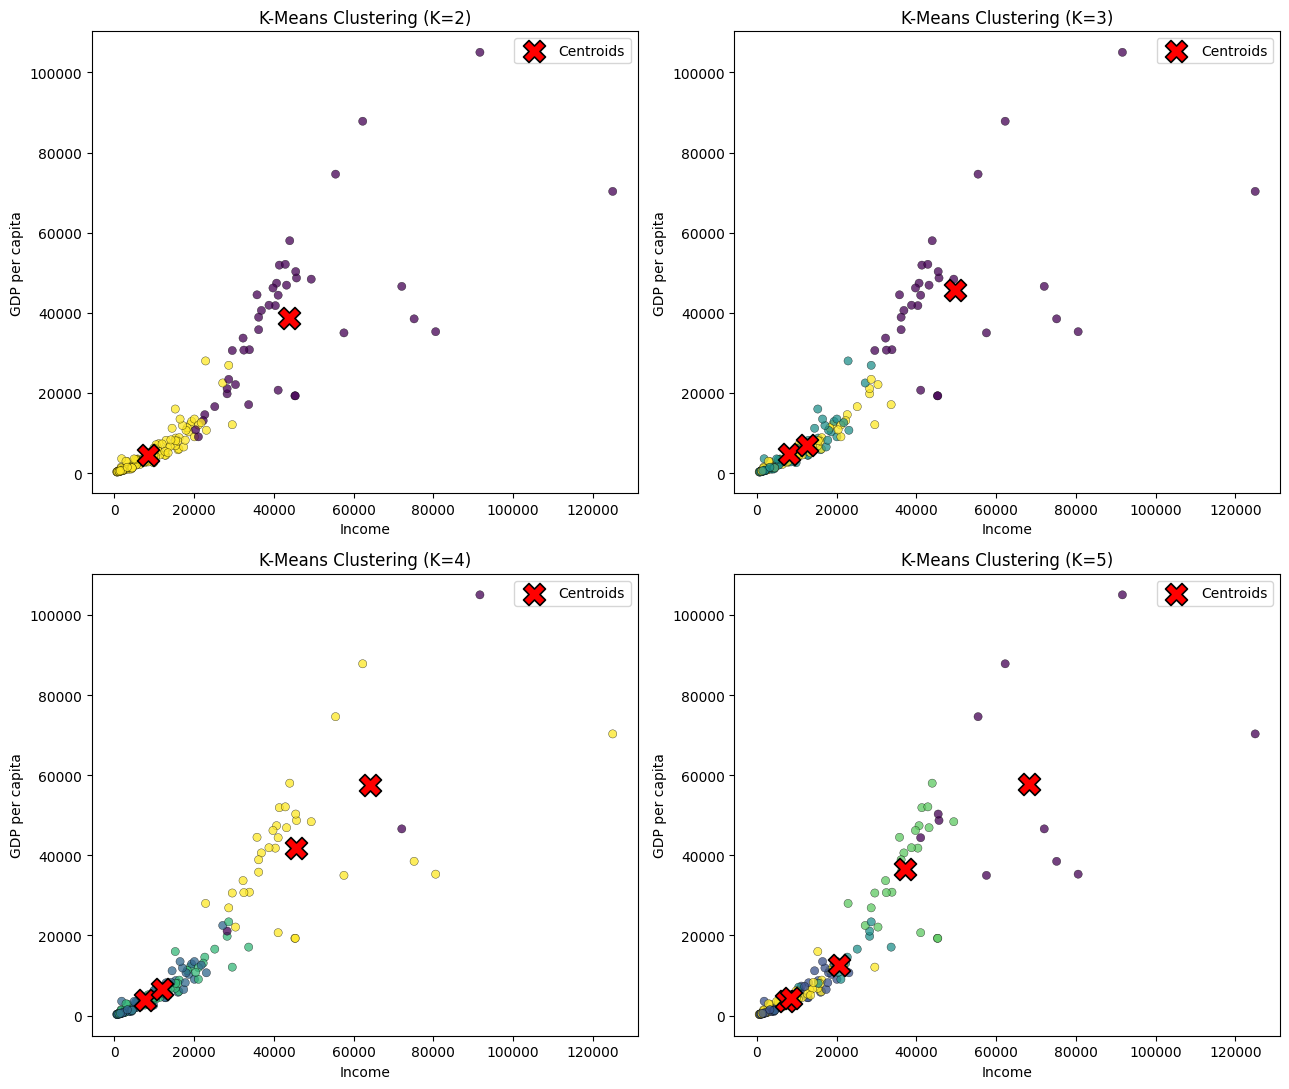

In [ ]:
import matplotlib.pyplot as plt

income_idx = features.index('income')
gdpp_idx = features.index('gdpp')

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, k in zip(axes, k_values):
    clusters = results[k]['clusters']
    centroids = results[k]['centroids']

    xs = [raw_data[i][income_idx] for i in range(len(raw_data))]
    ys = [raw_data[i][gdpp_idx] for i in range(len(raw_data))]

    scatter = ax.scatter(xs, ys, c=clusters, cmap='viridis', s=35, alpha=0.75, edgecolor='k', linewidth=0.3)

    # de-standardize centroids back to original scale for plotting
    cx = [c[income_idx] * feat_stds[income_idx] + feat_means[income_idx] for c in centroids]
    cy = [c[gdpp_idx] * feat_stds[gdpp_idx] + feat_means[gdpp_idx] for c in centroids]
    ax.scatter(cx, cy, marker='X', s=250, c='red', edgecolor='black', linewidth=1.2, label='Centroids')

    ax.set_title(f'K-Means Clustering (K={k})')
    ax.set_xlabel('Income')
    ax.set_ylabel('GDP per capita')
    ax.legend()

plt.tight_layout()
plt.show()


## 8. Evaluating Cluster Quality

- **Elbow Method (WCSS):** decreases as K grows; look for the "elbow" where the drop slows down.
- **Silhouette Score:** measures compactness + separation of clusters (higher = better).

Both were computed with the pure-Python functions above; `matplotlib` here is only used to draw the summary charts.


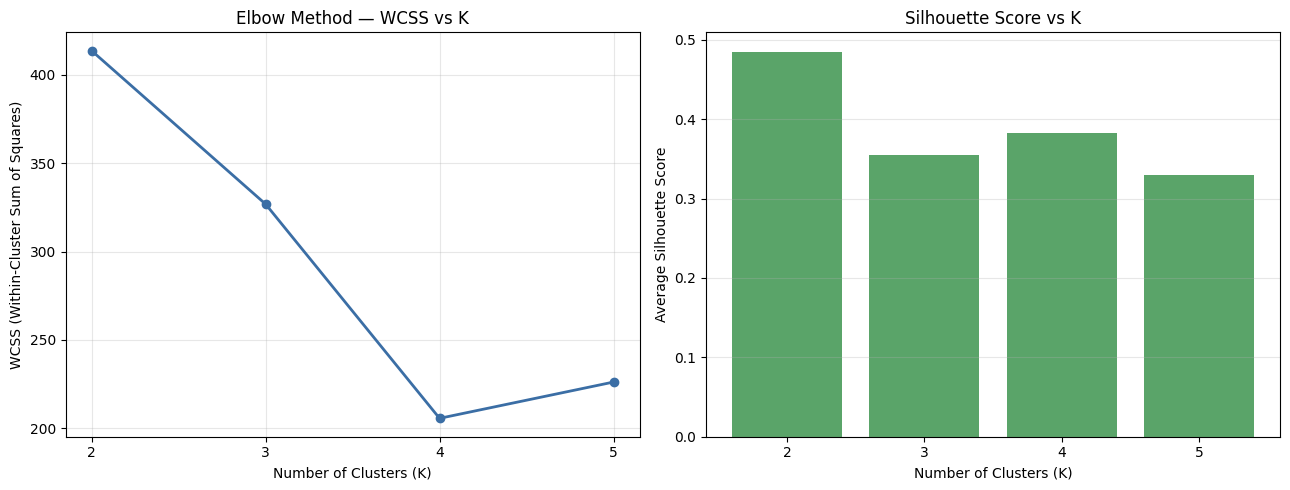

Summary:
  K=2: WCSS = 413.67, Silhouette Score = 0.4850
  K=3: WCSS = 326.84, Silhouette Score = 0.3551
  K=4: WCSS = 205.57, Silhouette Score = 0.3827
  K=5: WCSS = 226.12, Silhouette Score = 0.3300

Based on the Silhouette Score, the best number of clusters is K = 2.


In [ ]:
wcss_values = [results[k]['wcss'] for k in k_values]
sil_values = [results[k]['silhouette'] for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_values, wcss_values, marker='o', linewidth=2, color='#3b6ea5')
axes[0].set_title('Elbow Method — WCSS vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)')
axes[0].set_xticks(k_values)
axes[0].grid(alpha=0.3)

axes[1].bar([str(k) for k in k_values], sil_values, color='#5aa469')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Average Silhouette Score')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Summary:")
for k in k_values:
    print(f"  K={k}: WCSS = {results[k]['wcss']:.2f}, Silhouette Score = {results[k]['silhouette']:.4f}")

best_k = k_values[sil_values.index(max(sil_values))]
print(f"\nBased on the Silhouette Score, the best number of clusters is K = {best_k}.")


## 9. Inspecting the Final Clusters (Best K)


In [ ]:
best_k = k_values[sil_values.index(max(sil_values))]
best_clusters = results[best_k]['clusters']

# group country names + income/gdpp by cluster, using plain Python lists/dicts
clustered_countries = {c: [] for c in range(best_k)}
for name, point, c in zip(country_names, raw_data, best_clusters):
    clustered_countries[c].append((name, point[income_idx], point[gdpp_idx]))

print(f"Cluster sizes for K={best_k}:")
for c in range(best_k):
    print(f"  Cluster {c}: {len(clustered_countries[c])} countries")

for c in range(best_k):
    print(f"\n--- Cluster {c} (n={len(clustered_countries[c])}) — top 8 by GDP per capita ---")
    sorted_members = sorted(clustered_countries[c], key=lambda x: x[2], reverse=True)
    for name, income, gdpp in sorted_members[:8]:
        print(f"  {name:35s} income={income:>10.1f}  gdpp={gdpp:>10.1f}")


Cluster sizes for K=2:
  Cluster 0: 41 countries
  Cluster 1: 126 countries

--- Cluster 0 (n=41) — top 8 by GDP per capita ---
  Luxembourg                          income=   91700.0  gdpp=  105000.0
  Norway                              income=   62300.0  gdpp=   87800.0
  Switzerland                         income=   55500.0  gdpp=   74600.0
  Qatar                               income=  125000.0  gdpp=   70300.0
  Denmark                             income=   44000.0  gdpp=   58000.0
  Sweden                              income=   42900.0  gdpp=   52100.0
  Australia                           income=   41400.0  gdpp=   51900.0
  Netherlands                         income=   45500.0  gdpp=   50300.0

--- Cluster 1 (n=126) — top 8 by GDP per capita ---
  Bahamas                             income=   22900.0  gdpp=   28000.0
  Greece                              income=   28700.0  gdpp=   26900.0
  Portugal                            income=   27200.0  gdpp=   22500.0
  Barbados      

## 10. Conclusion

- Every step of K-Means — Euclidean distance, random centroid initialization, cluster assignment, centroid recalculation, and the convergence loop — was implemented using **plain Python `list`s, `for` loops, and the built-in `math`/`random`/`csv` modules only**.
- **No `numpy`, `pandas`, or `sklearn`** was used anywhere in the data handling or the algorithm.
- `matplotlib` was used exclusively at the end to *draw* the charts — it did not perform any of the clustering math.
- The model was run for **K = 2, 3, 4, 5**, and evaluated with two hand-coded metrics: **WCSS (Elbow Method)** and **Silhouette Score**.
- The K with the highest silhouette score is reported above as the best choice.
